# Kleine Kernels: Wenn Framework-Overhead PyTorch ausbremst

Der **umgekehrte** Fall zum Hero-GEMM: bei **kleinen** Matrix-Multiplikationen dominiert bei PyTorch der **Dispatch-/Setup-Overhead** (Python-Aufruf, BLAS-Setup, AMX-Anlauf) — der lässt sich auf einem winzigen 16×16-Produkt nicht amortisieren. Ein **kompilierter TEIR-Kernel** ist dagegen ein direkter C-Funktionsaufruf in einer engen Schleife → **hier gewinnt TEIR deutlich**.

Wir fahren `ab-ac-cb` über wachsende Größen $N$ und suchen den **Crossover**: ab welcher Größe holt PyTorchs BLAS/AMX seinen Overhead wieder rein?

**Hardware:** Apple M4 Max. Frisch gemessen (kein TVM → schnell).


In [1]:
import os, subprocess, re, time
import torch
torch.set_num_threads(os.cpu_count() or 1)

SIZES = [16, 24, 32, 48, 64, 96, 128]
DIR = os.getcwd()
AUTO = os.path.dirname(os.path.dirname(DIR))  # notebooks/ -> eval/ -> autotuner/
COMPILER = os.path.join(AUTO, 'src', 'teir_compiler')

def bench(fn, warmup=30, iters=50, reps=5):
    for _ in range(warmup):
        fn()
    best = float('inf')
    for _ in range(reps):
        t0 = time.perf_counter()
        for _ in range(iters):
            fn()
        best = min(best, (time.perf_counter() - t0) / iters)
    return best

def teir(N):
    csv = os.path.join(DIR, '_ovh_one.csv')
    with open(csv, 'w') as f:
        f.write('name,tensors,axes,primitives,schedule,invokes,einsum\n')
        f.write(f'o,in0:f32;in1:f32;out:f32,a:{N};b:{N};c:{N},zero;gemm,'
                f'a:sequential;b:sequential;c:sequential,zero;gemm,ab-ac-cb\n')
    env = {**os.environ, 'TEIR_INPUT': csv, 'TEIR_STRATEGY': 'sa', 'TEIR_BACKEND': 'neon',
           'TEIR_MAX_TRIALS': '15', 'TEIR_TIME_BUDGET_MS': '600000', 'TEIR_SEARCH_OPT': '-O2'}
    out = subprocess.run([COMPILER], capture_output=True,
                         text=True, env=env, timeout=None).stdout  # keine Zeitgrenze
    m = re.search(r'\[PERFORMANCE\]\s+[\d.eE+-]+\s+ms\s+\(([\d.eE+-]+)', out)
    return float(m.group(1)) if m else float('nan')

rows = []
for N in SIZES:
    A = torch.randn(N, N); B = torch.randn(N, N); F = 2 * N**3
    mm = F / bench(lambda: torch.matmul(A, B)) / 1e9
    es = F / bench(lambda: torch.einsum('ac,cb->ab', A, B)) / 1e9
    tr = teir(N)
    rows.append((N, mm, es, tr))
    print(f'N={N:>4}:  torch.mm={mm:8.1f}  einsum={es:8.1f}  TEIR={tr:8.1f} GFLOPS', flush=True)


N=  16:  torch.mm=     9.4  einsum=     1.2  TEIR=    97.6 GFLOPS


N=  24:  torch.mm=    29.3  einsum=     3.8  TEIR=    83.4 GFLOPS


N=  32:  torch.mm=    71.4  einsum=     9.4  TEIR=    71.1 GFLOPS


N=  48:  torch.mm=   196.0  einsum=    30.8  TEIR=    65.3 GFLOPS


N=  64:  torch.mm=   388.4  einsum=    72.0  TEIR=    55.2 GFLOPS


N=  96:  torch.mm=   741.7  einsum=   209.1  TEIR=    52.2 GFLOPS


N= 128:  torch.mm=  1043.6  einsum=   411.6  TEIR=    48.4 GFLOPS


## Tabelle — wer gewinnt bei welcher Größe?

In [2]:
import pandas as pd
df = pd.DataFrame(rows, columns=['N', 'torch.matmul', 'torch.einsum', 'TEIR (neon)'])
df['Sieger'] = df[['torch.matmul', 'torch.einsum', 'TEIR (neon)']].idxmax(axis=1)
df['TEIR / torch.mm'] = (df['TEIR (neon)'] / df['torch.matmul']).round(2)
df


,N,torch.matmul,torch.einsum,TEIR (neon),Sieger,TEIR / torch.mm
0,16,9.380073,1.213928,97.5641,TEIR (neon),10.40
1,24,29.257100,3.797802,83.3576,TEIR (neon),2.85
2,32,71.428928,9.409332,71.0950,torch.matmul,1.00
3,48,196.026158,30.845005,65.2747,torch.matmul,0.33
4,64,388.361203,72.025903,55.2303,torch.matmul,0.14
5,96,741.655391,209.115914,52.2003,torch.matmul,0.07
6,128,1043.571870,411.609783,48.4389,torch.matmul,0.05


## Crossover-Kurve

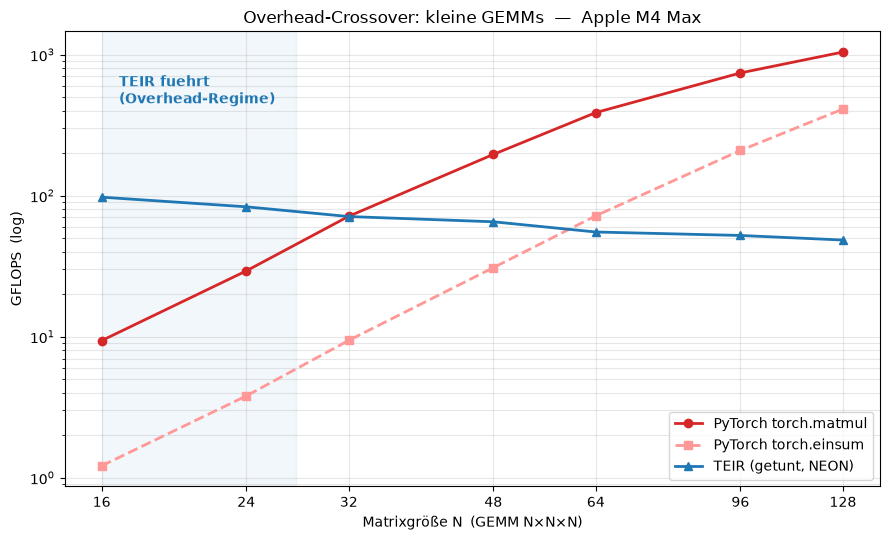

In [3]:
import matplotlib.pyplot as plt
N = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(N, [r[1] for r in rows], 'o-', label='PyTorch torch.matmul', color='#d62728', lw=2)
ax.plot(N, [r[2] for r in rows], 's--', label='PyTorch torch.einsum', color='#ff9896', lw=2)
ax.plot(N, [r[3] for r in rows], '^-', label='TEIR (getunt, NEON)', color='#1f77b4', lw=2)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xticks(N); ax.set_xticklabels(N)
ax.set_xlabel('Matrixgröße N  (GEMM N\u00d7N\u00d7N)')
ax.set_ylabel('GFLOPS  (log)')
ax.set_title('Overhead-Crossover: kleine GEMMs  \u2014  Apple M4 Max')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
# Bereich markieren, in dem TEIR fuehrt
lead = [n for n, r in zip(N, rows) if r[3] > r[1]]
if lead:
    ax.axvspan(min(N), max(lead) * 1.15, color='#1f77b4', alpha=0.06)
    ax.text(min(N) * 1.05, ax.get_ylim()[1] * 0.5, 'TEIR fuehrt\n(Overhead-Regime)',
            color='#1f77b4', fontsize=10, fontweight='bold', va='top')
plt.tight_layout(); plt.savefig('overhead_comparison.png', dpi=140); plt.show()


## Was das zeigt (ehrlich)

- **Bei kleinen N gewinnt TEIR — teils drastisch** (bei 16³ rund **10× vor `torch.matmul`**, ~75× vor `torch.einsum`). Grund: PyTorchs fixe Kosten pro Aufruf (Python-Dispatch, BLAS-/AMX-Setup) überwiegen die winzige Rechenlast; TEIRs kompilierter Kernel hat diesen Overhead nicht.
- **Ab dem Crossover (~32–64) dreht sich das:** die Rechenlast wird groß genug, dass PyTorchs BLAS/AMX seinen Overhead amortisiert und davonzieht (siehe Hero-Notebook).
- **`torch.einsum` liegt durchweg klar unter `torch.matmul`** — selbst innerhalb PyTorch kostet der einsum-Pfad (Planung + Umformen) spürbar.

**Ehrlicher Caveat:** bei sehr kleinen N sind die GFLOPS nahe am Messrauschen (Sub-Mikrosekunden-Rechenzeit) — der Sieg heißt genau genommen *„weniger Overhead", nicht „besserer Compute"*. Aber es ist ein **echter, praktischer Vorteil** für kleine oder einmalige Kernels: ein spezialisierter, kompilierter Kernel schlägt den Framework-Aufruf. Genau das ist eine Stärke des Codegen-/Autotuning-Ansatzes.
